<a href="https://colab.research.google.com/github/ElvinaShukurova/Telecom/blob/main/Lab8_Shukurova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

In [21]:
import numpy as np
import matplotlib.pyplot as plt


from thinkdsp import decorate
import scipy.signal
from scipy.signal.windows import gaussian

# Упражнение 8.1

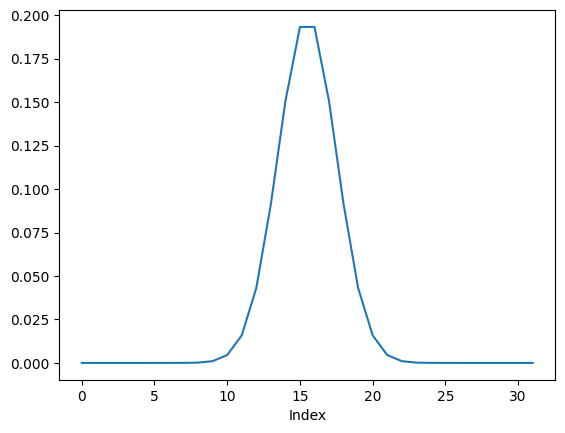

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import gaussian

gaussian = gaussian(M=32, std=2)
gaussian /= sum(gaussian)

plt.plot(gaussian)
plt.xlabel("Index")
plt.show()

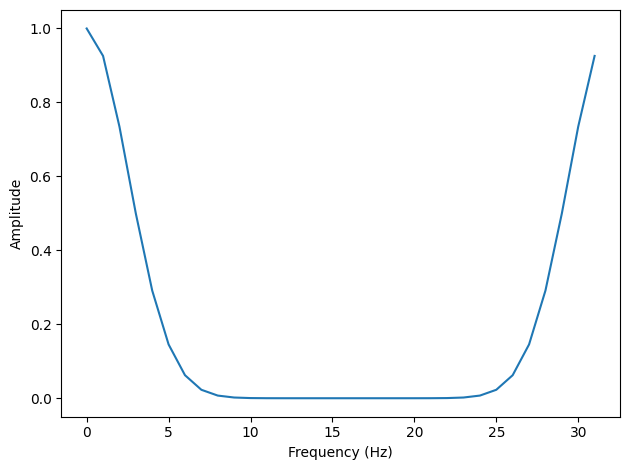

In [24]:
fft_gaussian = np.fft.fft(gaussian)
plt.plot(abs(fft_gaussian))
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

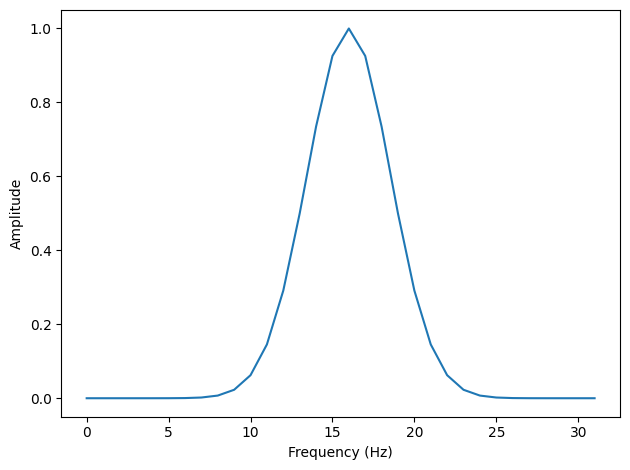

In [25]:
N = len(gaussian)
fft_rolled = np.roll(fft_gaussian, N//2)
plt.plot(abs(fft_rolled))
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

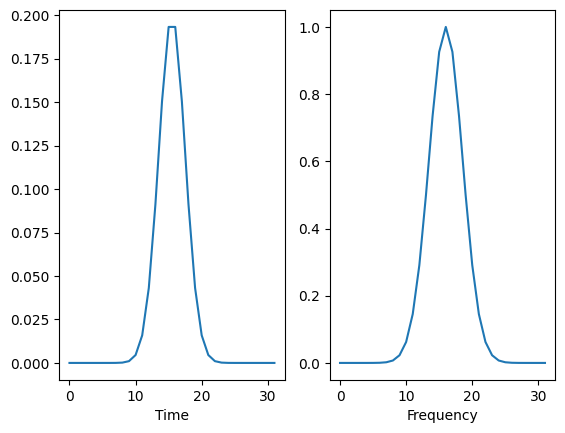

In [30]:

def plot_gaussian(std):
    M = 32

    g = gaussian(M=M, std=std)
    g /= np.sum(g)

    plt.subplot(1, 2, 1)
    plt.plot(g)
    plt.xlabel("Time")

    fft_g = np.fft.fft(g)
    fft_g = np.fft.fftshift(fft_g)

    plt.subplot(1, 2, 2)
    plt.plot(np.abs(fft_g))
    plt.xlabel("Frequency")

    plt.show()

plot_gaussian(2)

In [31]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider = widgets.FloatSlider(min=0.1, max=10, value=2)
interact(plot_gaussian, std=slider);

interactive(children=(FloatSlider(value=2.0, description='std', max=10.0, min=0.1), Output()), _dom_classes=('…

In [38]:
from thinkdsp import *
import scipy.signal
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets


def plot_filter(M=11, std=2):
    signal = SquareSignal(freq=440)
    wave = signal.make_wave(duration=1, framerate=44100)

    spectrum = wave.make_spectrum()

    window = scipy.signal.windows.gaussian(M=M, std=std)
    window /= np.sum(window)

    filtered_ys = np.convolve(wave.ys, window, mode='same')
    filtered_wave = Wave(filtered_ys, framerate=wave.framerate)

    spectrum_filtered = filtered_wave.make_spectrum()

    amps_original = spectrum.amps
    amps_filtered = spectrum_filtered.amps

    ratio = amps_filtered / amps_original
    ratio[amps_original < 560] = 0

    padded = np.zeros(len(wave))
    padded[:len(window)] = window

    dft_window = np.fft.rfft(padded)

    plt.plot(np.abs(dft_window), label='filter spectrum')
    plt.plot(ratio, label='amplitude ratio')
    plt.legend()

    plt.xlabel('Frequency')
    plt.ylabel('Amplitude')
    plt.show()


slider_M = widgets.IntSlider(min=2, max=100, value=11)
slider_std = widgets.FloatSlider(min=0.5, max=20, value=2)

interact(plot_filter, M=slider_M, std=slider_std)

interactive(children=(IntSlider(value=11, description='M', min=2), FloatSlider(value=2.0, description='std', m…

<function __main__.plot_filter(M=11, std=2)>

Если увеличивать std, но не увеличивать M, окно начинает обрезаться, что приводит к искажению его формы и ухудшению частотных свойств фильтра: растут боковые лепестки и увеличивается спектральная утечка.

# Упражнение 8.2

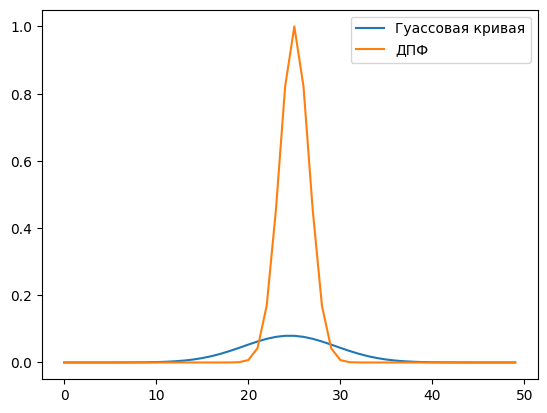

In [32]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
M = 50
std = 5
gaussian = scipy.signal.windows.gaussian(M, std)
gaussian /= sum(gaussian)
dft = np.fft.fft(gaussian)
dft = np.fft.fftshift(dft)
plt.plot(gaussian, label='Гуассовая кривая')
plt.plot(np.abs(dft), label='ДПФ')
plt.legend()

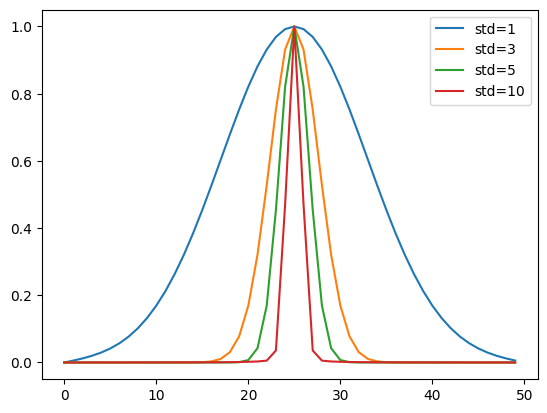

In [34]:
for std in [1, 3, 5, 10]:
    gaussian = scipy.signal.windows.gaussian(50, std)
    gaussian /= sum(gaussian)
    dft = np.fft.fft(gaussian)
    dft = np.fft.fftshift(dft)
    plt.plot(np.abs(dft), label=f'std={std}')
plt.legend()

Преобразование Фурье гауссовой функции снова даёт гауссову форму в частотной области. При увеличении параметра std гауссово окно во временной области становится шире, а его спектр, наоборот, сужается. При уменьшении std наблюдается обратный эффект. Это демонстрирует фундаментальное свойство преобразования Фурье: существует обратная зависимость между шириной сигнала во временной и частотной областях.

# Упражнение 8.3

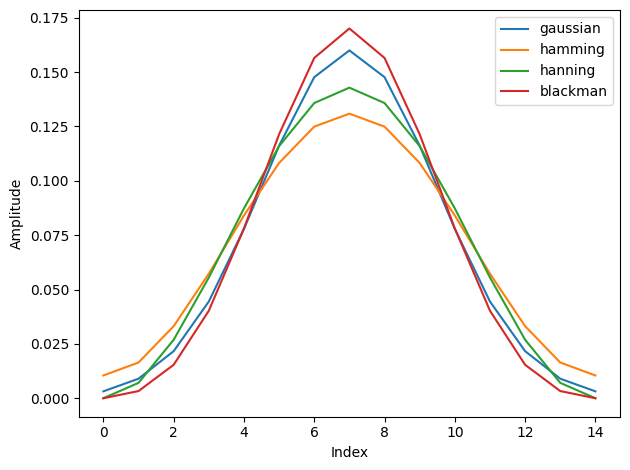

In [35]:
# Построение окон
M = 15
std = 2.5
gaussian = scipy.signal.windows.gaussian(M, std=std)
hamming = np.hamming(M)
hanning = np.hanning(M)
blackman = np.blackman(M)
windows = {
    'gaussian': gaussian,
    'hamming': hamming,
    'hanning': hanning,
    'blackman': blackman
}
for name in windows:
    windows[name] = windows[name] / windows[name].sum()
for name, window in windows.items():
    plt.plot(window, label=name)
decorate(xlabel='Index', ylabel='Amplitude')
plt.legend()

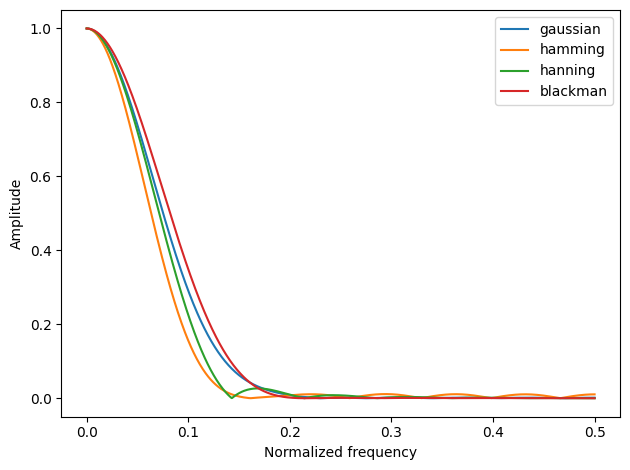

In [36]:
def zero_pad(array, n):
    result = np.zeros(n)
    result[:len(array)] = array
    return result
N = 2048
for name, window in windows.items():
    padded = zero_pad(window, N)
    spectrum = np.fft.rfft(padded)
    freqs = np.linspace(0, 0.5, len(spectrum))
    plt.plot(freqs, np.abs(spectrum), label=name)
    decorate(xlabel='Normalized frequency', ylabel='Amplitude')
plt.legend()

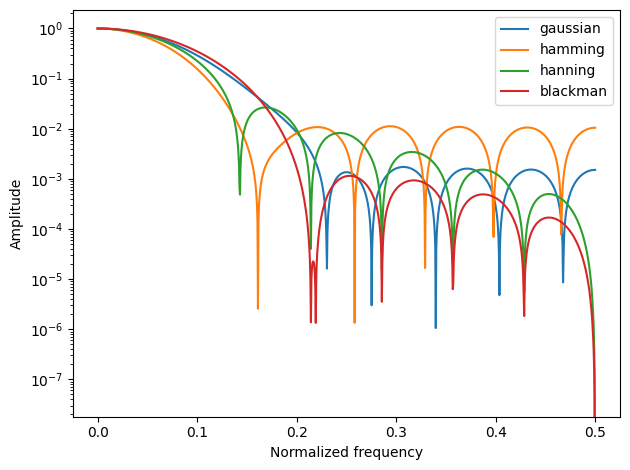

In [37]:
N = 2048
for name, window in windows.items():
    padded = zero_pad(window, N)
    spectrum = np.fft.rfft(padded)
    freqs = np.linspace(0, 0.5, len(spectrum))
    plt.plot(freqs, np.abs(spectrum), label=name)
decorate(
    xlabel='Normalized frequency',
    ylabel='Amplitude',
    yscale='log'
)
plt.legend()

Рассмотрены гауссово окно, а также окна Хэмминга, Хэннинга и Блэкмана. Во временной области их формы во многом схожи, однако в частотной области различия становятся значительно более выраженными. В логарифмическом масштабе видно, что окна отличаются уровнем боковых лепестков: более гладкие окна обеспечивают меньшую спектральную утечку. Таким образом, выбор окна существенно влияет на точность спектрального анализа и качество фильтрации сигналов.